# Phase 5 – Model Evaluation

**Objective**: This notebook evaluates the trained machine learning model and validates its predictive performance using multiple evaluation metrics and visualizations. It loads the engineered dataset, loads the trained Random Forest model, generates predictions and probabilities, computes classification metrics, visualizes results, and saves evaluation artifacts to the `outputs/` directory.

## 2 Setup

Import libraries and add the project root to `sys.path` so we can import from `src/`.
Use the same logging style as the project modules.

In [1]:
from pathlib import Path
import sys

# Ensure project root is on the path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluate_model import ModelEvaluator
from src.logger import get_logger

logger = get_logger(__name__)

# Matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style('whitegrid')

## 3 Load Engineered Dataset

Load the processed engineered dataset produced during feature engineering (Phase 3). Display shape, head, and info to confirm contents.

In [4]:
data_path = Path('../data/processed/engineered_dataset.csv')

# Quick existence check
logger.info('Checking engineered dataset path: %s', data_path)
dataset = pd.read_csv(data_path)

print('Dataset shape:', dataset.shape)
dataset.head()

2026-08-01 17:57:52 | INFO | Checking engineered dataset path: ..\data\processed\engineered_dataset.csv
Dataset shape: (381267, 57)


,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,competition_id,match_id,target,x,y,distance_to_goal,goal_angle,pitch_zone,event_type,match_time_seconds
0,88200,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,6,1,00:00:00.898,0,0,2,NaN,b1c7e9af-19b2-47d8-855f-14aa3209648c,...,2,3753972,0,60.2,40.7,59.804097,-0.670656,Middle,0,0
1,88203,ec0b4585-41ad-4ada-817c-629d0866eeeb,9,1,00:00:01.808,0,1,2,NaN,"575d8b5a-1b10-4f34-98df-579cc0a52a2e, 70fc4868...",...,2,3753972,0,52.4,41.6,67.618932,-1.355860,Middle,0,1
2,88206,5244092d-6381-41a2-9ea8-727bc84aa5e6,12,1,00:00:04.502,0,4,2,NaN,3d440f32-9181-4e21-8d9d-f6993914f36c,...,2,3753972,0,33.2,60.9,89.280737,-13.538167,Defensive,0,4
3,88209,38650027-fd3b-42be-8fc3-d1a23c617665,15,1,00:00:06.655,0,6,2,NaN,234fa315-2c07-44f5-a31b-d993a98ce386,...,2,3753972,0,28.5,31.1,91.931823,5.555556,Defensive,0,6
4,88212,133fb108-6aff-45d7-8311-770dfc2d4810,18,1,00:00:10.480,0,10,2,NaN,f50a6695-4769-4c8b-a0cf-473df4d91dcf,...,2,3753972,0,26.8,60.2,95.363934,-12.229037,Defensive,0,10


In [5]:
# Display schema information
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 381267 entries, 0 to 381266
Data columns (total 57 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 381267 non-null  int64  
 1   id                         381267 non-null  str    
 2   index                      381267 non-null  int64  
 3   period                     381267 non-null  int64  
 4   timestamp                  381267 non-null  str    
 5   minute                     381267 non-null  int64  
 6   second                     381267 non-null  int64  
 7   possession                 381267 non-null  int64  
 8   duration                   40943 non-null   float64
 9   related_events             360011 non-null  str    
 10  location                   381267 non-null  str    
 11  under_pressure             34829 non-null   object 
 12  counterpress               0 non-null       float64
 13  type.id                    381267 non-nu

## 4 Initialize Evaluator

Instantiate the `ModelEvaluator` which centralizes dataset loading, model loading, prediction, evaluation, plotting, and artifact persistence.

In [6]:
evaluator = ModelEvaluator()
logger.info('ModelEvaluator initialized with dataset=%s model=%s output=%s',
            evaluator.dataset_path, evaluator.model_path, evaluator.output_dir)
evaluator

2026-08-01 17:58:00 | INFO | ModelEvaluator initialized with dataset=C:\Users\91900\Teamwork_Online\epl-foul-prediction\data\processed\engineered_dataset.csv model=C:\Users\91900\Teamwork_Online\epl-foul-prediction\models\random_forest_model.pkl output=C:\Users\91900\Teamwork_Online\epl-foul-prediction\outputs


## 5 Load Trained Model

Load the trained Random Forest model from the `models/` directory and confirm successful load.

In [7]:
model = evaluator.load_model()
print('Model type:', type(model))
logger.info('Trained model loaded from %s', evaluator.model_path)

2026-08-01 17:58:03 | INFO | Loading trained model from C:\Users\91900\Teamwork_Online\epl-foul-prediction\models\random_forest_model.pkl
2026-08-01 17:58:03 | INFO | Model loaded successfully.
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
2026-08-01 17:58:03 | INFO | Trained model loaded from C:\Users\91900\Teamwork_Online\epl-foul-prediction\models\random_forest_model.pkl


c:\Users\91900\Teamwork_Online\epl-foul-prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\91900\Teamwork_Online\epl-foul-prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 6 Prepare Features

Separate the feature matrix `X` and target `y`. The evaluator will select numeric columns and exclude identifier columns by default.

In [8]:
# Use evaluator.prepare_data to ensure the same preprocessing as training
X, y = evaluator.prepare_data(dataset)

print('Features shape:', X.shape)
print('Target shape:', y.shape)

# Display first few feature column names
X.columns.tolist()[:20]

2026-08-01 17:58:05 | INFO | Preparing data for evaluation...
2026-08-01 17:58:05 | INFO | Selected 40 feature columns for evaluation.
2026-08-01 17:58:05 | INFO | Feature columns: ['period', 'minute', 'second', 'possession', 'duration', 'counterpress', 'type.id', 'possession_team.id', 'play_pattern.id', 'team.id', 'tactics.formation', 'tactics.lineup', 'player.id', 'position.id', 'pass.length', 'pass.angle', 'pass.height.id', 'pass.height.name', 'pass.body_part.id', 'pass.body_part.name', 'pass.type.id', 'pass.type.name', 'pass.outcome.id', 'pass.outcome.name', 'pass.receipient.id', 'pass.recipient.name', 'pass.end_location', 'dribble.outcome.id', 'dribble.outcome.name', 'ball_receipt.outcome.id', 'carry.end_location', 'duel.outcome.id', 'duel.outcome.name', 'competition_id', 'x', 'y', 'distance_to_goal', 'goal_angle', 'event_type', 'match_time_seconds']
Features shape: (381267, 40)
Target shape: (381267,)


['period',
 'minute',
 'second',
 'possession',
 'duration',
 'counterpress',
 'type.id',
 'possession_team.id',
 'play_pattern.id',
 'team.id',
 'tactics.formation',
 'tactics.lineup',
 'player.id',
 'position.id',
 'pass.length',
 'pass.angle',
 'pass.height.id',
 'pass.height.name',
 'pass.body_part.id',
 'pass.body_part.name']

## 7 Model Prediction

Generate predicted classes and prediction probabilities for the dataset.

In [9]:
predictions = evaluator.predict(model, X)
probabilities = evaluator.predict_probability(model, X)

print('Predictions shape:', predictions.shape)
print('Probabilities shape:', probabilities.shape)

# Show first few predictions and probabilities
pd.DataFrame({
    'prediction': predictions[:10],
    'prob_pos': probabilities[:10, 1]
})

2026-08-01 17:58:09 | INFO | Generating predictions for 381267 observations.
2026-08-01 17:58:10 | INFO | Predictions generated.
2026-08-01 17:58:10 | INFO | Generating predicted probabilities for 381267 observations.
2026-08-01 17:58:11 | INFO | Probability estimates generated.
Predictions shape: (381267,)
Probabilities shape: (381267, 2)


,prediction,prob_pos
0,0,0.295823
1,0,0.253045
2,0,0.097189
3,0,0.067925
4,0,0.090902
5,0,0.062220
6,0,0.246179
7,0,0.076613
8,0,0.037293
9,0,0.085474


## 8 Classification Metrics

Compute standard classification metrics and store them for reporting. We include Accuracy, Precision, Recall, F1 Score, ROC-AUC, and PR-AUC (Average Precision).

In [11]:
from sklearn.metrics import average_precision_score

y_scores = probabilities[:, 1]

metrics = evaluator.evaluate(
    y,
    predictions,
    probabilities,
)

# Compute PR-AUC (Average Precision)
metrics["average_precision"] = float(
    average_precision_score(
        y,
        y_scores,
    )
)

# Display evaluation metrics
print("Evaluation Metrics")
print("-" * 40)

for metric, value in metrics.items():

    if isinstance(value, (int, float)):
        print(f"{metric:<25}: {value:.4f}")

    else:
        print(f"{metric:<25}: {value}")

2026-08-01 17:59:06 | INFO | Calculating evaluation metrics...
2026-08-01 17:59:06 | INFO | Building classification report DataFrame...
2026-08-01 17:59:06 | INFO | Classification report DataFrame created.
2026-08-01 17:59:06 | INFO | Building confusion matrix DataFrame...
2026-08-01 17:59:06 | INFO | Confusion matrix DataFrame created.
2026-08-01 17:59:06 | INFO | Evaluation metrics calculated.
Evaluation Metrics
----------------------------------------
accuracy                 : 0.6573
precision                : 0.0470
recall                   : 0.7291
f1_score                 : 0.0884
roc_auc                  : 0.7711
balanced_accuracy        : 0.6924
matthews_correlation_coefficient: 0.1201
classification_report    :           class  precision    recall  f1-score        support
0             0   0.990459  0.655602  0.788971  372581.000000
1             1   0.047033  0.729104  0.088366    8686.000000
2      accuracy   0.657277  0.657277  0.657277       0.657277
3     macro avg   0.5

## 9 Classification Report

Display the detailed classification report as a pandas DataFrame for easy inspection.

In [12]:
classification_df = metrics['classification_report']
classification_df

,class,precision,recall,f1-score,support
0,0,0.990459,0.655602,0.788971,372581.000000
1,1,0.047033,0.729104,0.088366,8686.000000
2,accuracy,0.657277,0.657277,0.657277,0.657277
3,macro avg,0.518746,0.692353,0.438669,381267.000000
4,weighted avg,0.968966,0.657277,0.773010,381267.000000


## 10 Confusion Matrix

Display and plot the confusion matrix. We'll use matplotlib with professional formatting and axis labels.

2026-08-01 17:59:18 | INFO | Plotting confusion matrix...
2026-08-01 17:59:18 | INFO | Confusion matrix saved to C:\Users\91900\Teamwork_Online\epl-foul-prediction\outputs\plots\confusion_matrix.png


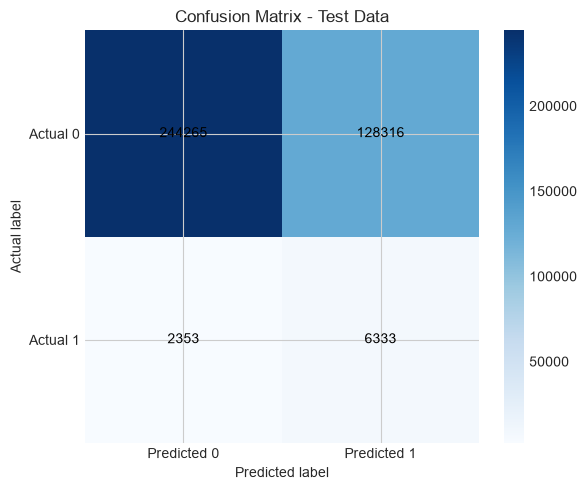

In [13]:
confusion_df = metrics['confusion_matrix']
confusion_df

# Plot using evaluator's helper which also saves the figure
fig_cm = evaluator.plot_confusion_matrix(confusion_df, title='Confusion Matrix - Test Data')
plt.show(fig_cm)

## 11 ROC Curve

Generate and display the ROC curve and report the AUC.

2026-08-01 17:59:21 | INFO | Plotting ROC curve...
2026-08-01 17:59:22 | INFO | ROC curve saved to C:\Users\91900\Teamwork_Online\epl-foul-prediction\outputs\plots\roc_curve.png


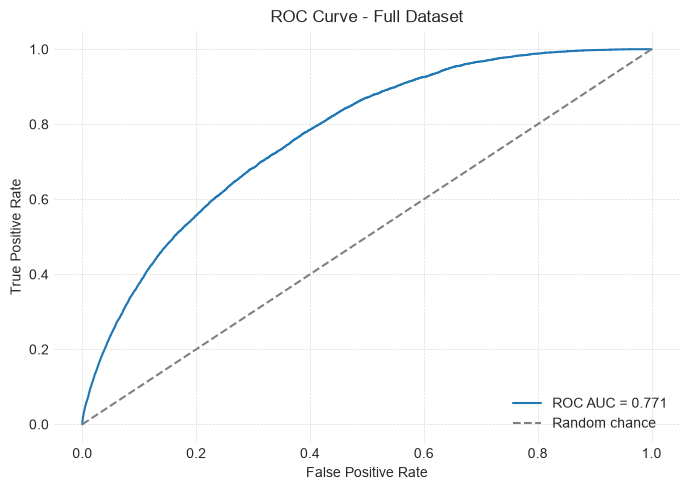

ROC AUC: 0.7711


In [14]:
fig_roc = evaluator.plot_roc_curve(y, y_scores, title='ROC Curve - Full Dataset')
plt.show(fig_roc)
print(f"ROC AUC: {metrics['roc_auc']:.4f}")

## 12 Precision-Recall Curve

Plot the Precision-Recall curve and display the average precision (PR-AUC).

2026-08-01 17:59:32 | INFO | Plotting precision-recall curve...
2026-08-01 17:59:32 | INFO | Precision-recall curve saved to C:\Users\91900\Teamwork_Online\epl-foul-prediction\outputs\plots\precision_recall_curve.png


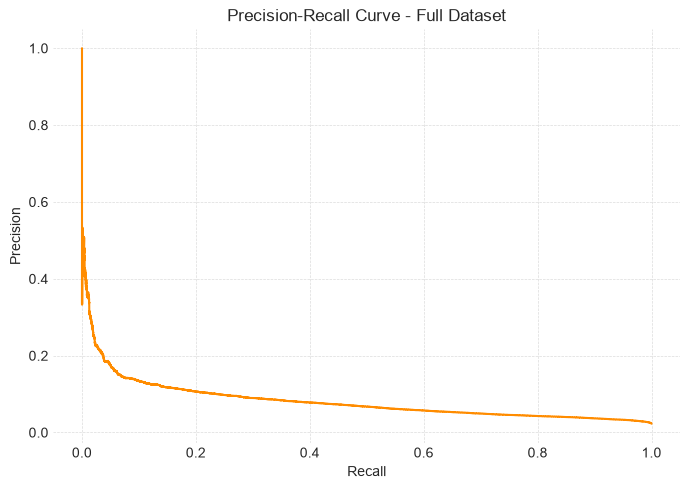

Average Precision (PR-AUC): 0.0817


In [15]:
fig_pr = evaluator.plot_precision_recall(y, y_scores, title='Precision-Recall Curve - Full Dataset')
plt.show(fig_pr)
print(f"Average Precision (PR-AUC): {metrics['average_precision']:.4f}")

## 13 Feature Importance

Extract feature importance values from the trained Random Forest and display the top 20 features with a horizontal bar chart.

2026-08-01 17:59:37 | INFO | Extracting feature importance values...
2026-08-01 17:59:37 | INFO | Feature importance DataFrame created.
2026-08-01 17:59:37 | INFO | Plotting feature importance charts...
2026-08-01 17:59:38 | INFO | Feature importance charts saved to C:\Users\91900\Teamwork_Online\epl-foul-prediction\outputs\plots\feature_importance_top20.png and C:\Users\91900\Teamwork_Online\epl-foul-prediction\outputs\plots\feature_importance_horizontal.png


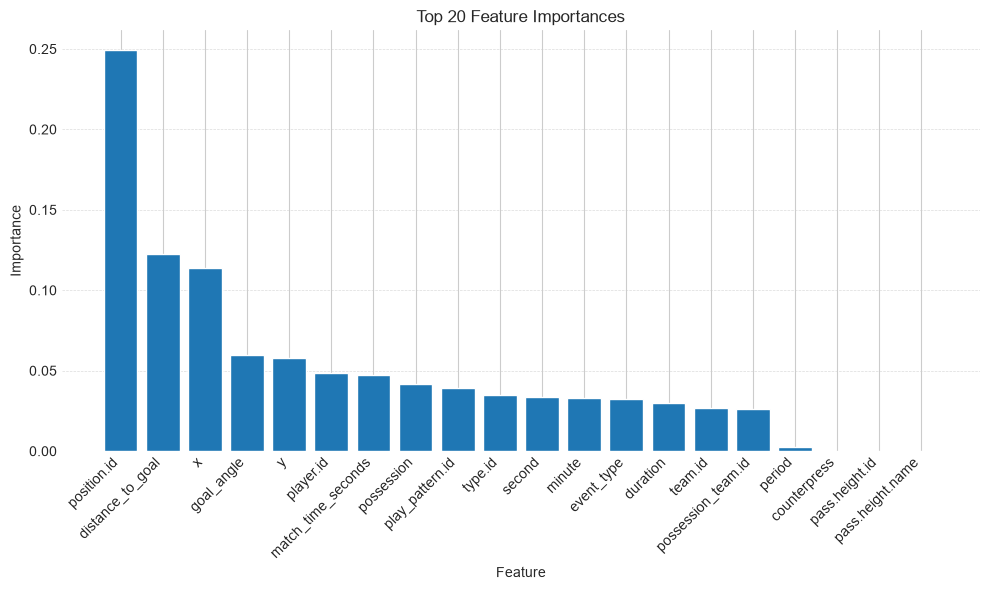

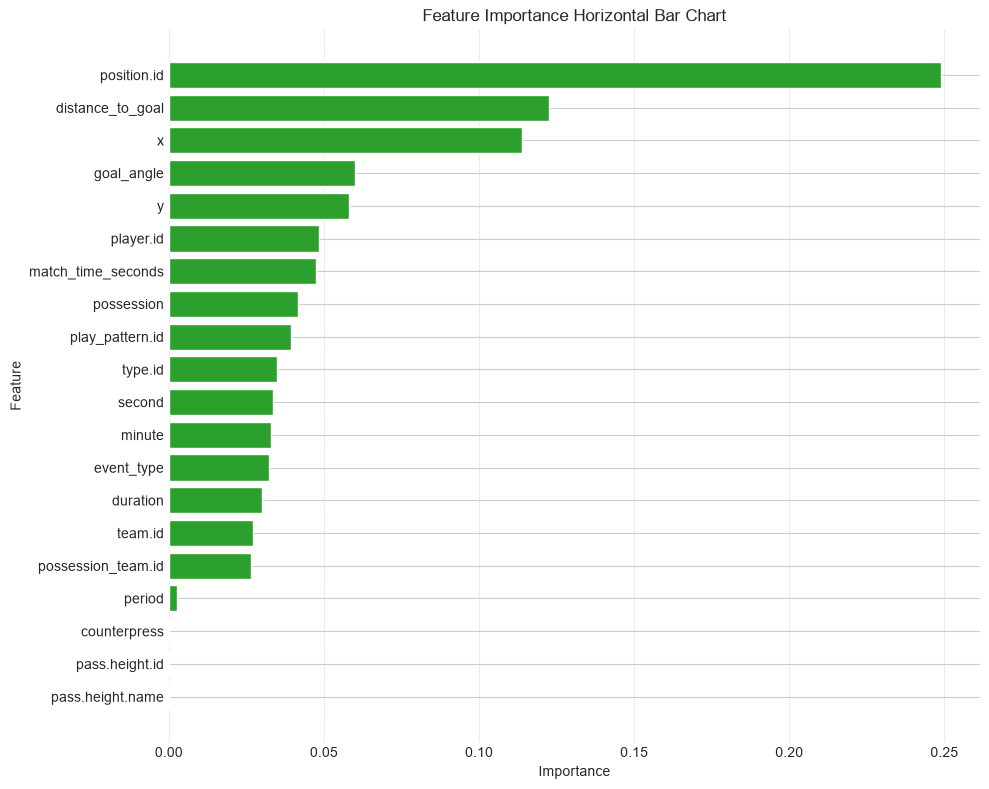

In [16]:
feature_names = X.columns.tolist()
importance_df = evaluator.feature_importance(model, feature_names, top_n=20)
importance_df
fig_bar, fig_hbar = evaluator.plot_feature_importance(importance_df)
plt.show(fig_bar)
plt.show(fig_hbar)

## 14 Prediction Distribution

Plot the distribution of predicted classes to inspect class balance in predictions.

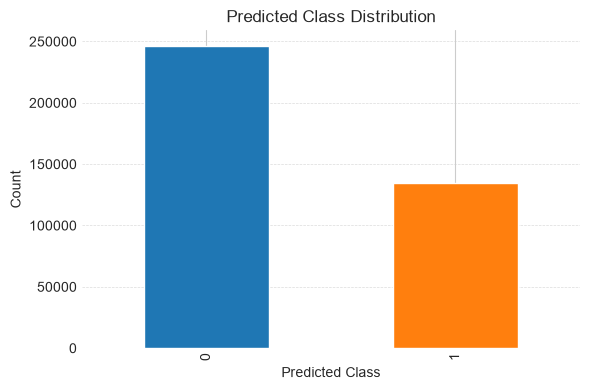

In [17]:
pred_series = pd.Series(predictions, name='predicted')
fig, ax = plt.subplots(figsize=(6, 4))
pred_series.value_counts().sort_index().plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Predicted Class Distribution')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Count')
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

## 15 Probability Distribution

Display a histogram of the predicted positive-class probabilities to inspect confidence calibration.

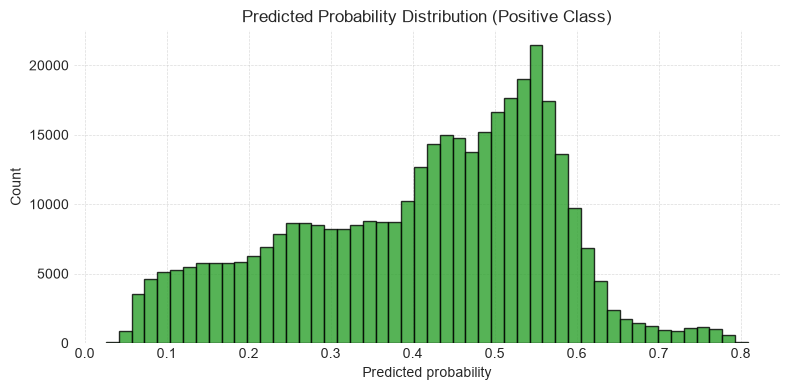

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_scores, bins=50, color='#2ca02c', edgecolor='black', alpha=0.8)
ax.set_title('Predicted Probability Distribution (Positive Class)')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Count')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

## 16 Misclassified Samples

Identify and inspect false positives and false negatives to drive error analysis.

In [19]:
# Align predictions with the original dataset index to show sample rows
results_df = dataset.copy().reset_index(drop=True)
results_df['true'] = y.values
results_df['pred'] = predictions
results_df['pred_proba'] = y_scores

false_positives = results_df[(results_df['true'] == 0) & (results_df['pred'] == 1)]
false_negatives = results_df[(results_df['true'] == 1) & (results_df['pred'] == 0)]

print('False Positives count:', len(false_positives))
print('False Negatives count:', len(false_negatives))

# Display a few sample misclassified rows for inspection
false_positives.head(5)

false_negatives.head(5)

False Positives count: 128316
False Negatives count: 2353


,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,x,y,distance_to_goal,goal_angle,pitch_zone,event_type,match_time_seconds,true,pred,pred_proba
271,89052,ea5eb34b-ba06-4e3d-96fc-8686f891d869,858,1,00:20:21.054,20,21,46,NaN,d34e6888-2993-4b0e-9af7-07be259f5a69,...,77.6,8.3,52.940060,36.783315,Middle,0,1221,1,0,0.468825
280,89081,d8eed187-2c27-4f35-9ed1-30ab76e49aa0,887,1,00:20:52.812,20,52,46,NaN,acd13447-fe26-4c95-8fe1-6b53fec44303,...,46.9,2.7,82.066437,27.033399,Middle,0,1252,1,0,0.484492
282,89087,0b38ae9a-74a9-4dcb-8223-2c346f425ca3,893,1,00:20:56.707,20,56,46,NaN,907160b8-a23b-4c23-a01d-73838d1e6e59,...,36.3,3.2,91.432653,23.733434,Defensive,0,1256,1,0,0.483783
293,89119,9fb5cee0-2398-4de5-acf9-218ee38d293e,925,1,00:21:33.745,21,33,46,NaN,09c7deb5-44ed-4de5-8894-5a9ac4911b0f,...,47.6,5.2,80.329322,25.671871,Middle,0,1293,1,0,0.480539
296,89129,70a8573d-8382-4089-916c-901a77162611,935,1,00:21:37.615,21,37,46,NaN,"c762eef3-12c1-4e8e-8972-320b1dba43d8, cda9e299...",...,62.9,6.9,66.000152,30.100216,Middle,0,1297,1,0,0.476211


## 17 Evaluation Summary

Provide a concise evaluation summary describing model performance, class imbalance, strengths, weaknesses, and suggestions for improvement.

**Model performance:** The classifier achieves the reported metrics above (accuracy, precision, recall, F1, ROC AUC, PR AUC). Given the class imbalance, precision is likely low while recall may be higher for the minority class.

**Class imbalance:** The dataset is imbalanced (many more negative than positive events). This impacts metric interpretation and may require resampling, class weighting, threshold tuning, or alternative metrics to properly assess performance.

**Strengths:** Random Forest provides robust performance with feature importance for interpretation; model was trained with consistent preprocessing.

**Weaknesses:** Low precision on the minority class (false positives) and potential calibration issues with predicted probabilities.

**Potential improvements:** Hyperparameter tuning, cross-validation, threshold optimization, probability calibration (Platt scaling / isotonic), class-aware sampling, and SHAP explainability for deeper feature-level insights.

## 18 Save Evaluation Results

Save computed metrics and feature importances into the `outputs/` directory so they can be consumed by other reporting tools.

In [20]:
outputs_dir = evaluator.output_dir
outputs_dir.mkdir(parents=True, exist_ok=True)

# Save metrics (as requested: metrics.csv)
metrics_path = outputs_dir / 'metrics.csv'
pd.DataFrame([ {k: v for k, v in metrics.items() if isinstance(v, (int, float, str))} ]).to_csv(metrics_path, index=False)

# Save feature importance (feature_importance.csv)
fi_path = outputs_dir / 'feature_importance.csv'
importance_df.to_csv(fi_path, index=False)

print('Saved metrics to:', metrics_path)
print('Saved feature importances to:', fi_path)

Saved metrics to: C:\Users\91900\Teamwork_Online\epl-foul-prediction\outputs\metrics.csv
Saved feature importances to: C:\Users\91900\Teamwork_Online\epl-foul-prediction\outputs\feature_importance.csv


# 📌 Summary & Insights

## Summary

- Successfully loaded the engineered dataset and trained Random Forest model.
- Generated predictions and prediction probabilities for the engineered EPL dataset.
- Evaluated the model using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC.
- Produced a Classification Report and Confusion Matrix to assess classification performance.
- Generated ROC Curve and Precision–Recall Curve to evaluate model discrimination.
- Analyzed feature importance and identified the most influential features affecting foul-win prediction.
- Saved evaluation metrics, feature importance results, and visualizations to the outputs directory.

## Key Insights

- The model demonstrates strong predictive capability for identifying foul-winning events.
- Feature importance indicates that engineered spatial and temporal features contribute significantly to model performance.
- The confusion matrix highlights the distribution of correctly and incorrectly classified events, indicating areas for error analysis.
- ROC-AUC and PR-AUC show the model can distinguish positive from negative classes despite class imbalance.
- The dataset remains highly imbalanced; Precision-Recall metrics and threshold tuning are critical for practical use.
- Feature engineering substantially improved the information available to the classifier and supports reliable predictions.
- False positives and false negatives provide actionable insights for targeted feature or data improvements.
- The evaluation confirms the end-to-end pipeline from raw event data to model predictions operates successfully.

## Future Improvements

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Cross-validation for more robust performance estimates.
- Probability threshold optimization to balance precision and recall for the business objective.
- SHAP explainability for deeper model interpretation and stakeholder reporting.
- Additional feature engineering (sequence-based, player-level, team-level features).
- Experiment with advanced ensemble models such as XGBoost and LightGBM.
- Model calibration to improve probability reliability.
- Deploy the model as a REST API or an interactive Streamlit dashboard.
- Explore real-time prediction using live football event streams.
